# STOR609 Pig Report - James Marriner.

Our aim is to create the dice game Pig in Python using functional patterns in a similar vein to the Iterated Prisoner's Dilemma and to perform a short numerical study.

In [1]:
import PigFunctions_JamesMarriner as Pig

## Design Ideas

Ultimately, the goal is to assess the various performance of strategys in Pig. In traditional Pig, a player wins as soon as they reach or exceed the target. This clearly favours player 1 as they have an extra opportunity to reach the target compared to player 2. This means that if simulating strategies as a two player game, we will need to allow strategies to compete both as player 1 and as player 2. Further, we choose to ignore strategies competing against themselves as Pig is a win/lose game as opposed to the IPD.

## Code Philosophy

Allowing for flexibility in the number of dice faces used, as well as the number of dice used, we first need a function to act as a dice roller. This dice roller should in turn be used by various strategies which are themselves used by a 'turn' function which updates the players scores after they each make their respective moves. Further, this 'turn' function will be part of a 'match' function which plays each game to completion, and lastly this 'match' should be played for all prospective strategy pairs. This description highlights elements of functional composition which suggest the use of currying, and reduction to efficiently implement.

We mainly choose lists to store information throughout due to their convenience and the speed of operations performed on them. Occasionally dictionaries are used as in the final stage to store results and their associated strategies. Much of this list convenience relies specifically on the structures that appear in various functions. Thus if making further adaptations, such as allowing more than two players, more thought will be needed.

For two broad classes of strategies, we wish to determine which strategy is optimal for the game of Pig. We do this by allowing the strategies to compete in a round robin format as both player 1 and 2. We repeat this round robin n times in an effort to combat the stochasticity of dicerolling. We calculate each strategy's win percentage throughout the tournament and average this over macro replications. In this sense, the optimal strategy is defined by how often it succeeds against the other available strategies. Hence, whilst we hope to uncover the optimal strategy within those we consider, this is far from likely to be the globally optimal strategy.

We consider strategies where:
- A player always rolls n dice on their turn,
- A player continues to roll until they reach score x

Of course in the event that the player rolls a 1, their score for the turn becomes 0 and in the case that they reach the target in the middle of their turn, they also cease rolling.

With these we will aim to answer:
- Which parameters give the best strategy for a series of possible targets?
- How do the win percentages of our strategy change as the target changes?



## Simulation Parameters

We will consider the game of Pig where draws are not allowed. So, if player 1 reaches the target before player 2 can take their turn, the game immediately end. We will consider a single dice with 6 faces though our code is flexible in regards to both of these conditions. 

For our first strategy type we consider rolling a fixed number of dice from 1 to 5, and for our second, consider rolling until scores reach each multiple from 5 to 40. We then perform 1000 Macroreplications of our round robin tournament for various targets increasing in factors of 50 from 50 to 500. Lastly, we choose a seed before running our simulation in the interest of reproducibility.

In [2]:
Target_Values = range(50,550,50)

Named_Strategies = {Pig.Roll_n_times(x) :  f"Roll_{x}" for x in range(1,6)}

Named_Strategies.update({Pig.Roll_until_n(n) : f"Until_{n}" for n in range(5,45,5)})

import random
random.seed(369)

Sim_Res = Pig.Simulation(Strategies = Named_Strategies, n_plays = 1000, Draw = False, Target_vals = Target_Values, DiceRange = (1,6), n_dice= 1)

In [3]:
Best_Strategies = Pig.Max_Strats(Named_Strategies,Sim_Res)
print(Best_Strategies)

['Roll_4', 'Until_15', 'Until_15', 'Until_15', 'Roll_3', 'Until_15', 'Until_15', 'Until_15', 'Until_15', 'Until_10']


Subject to some stochasticity, we conclude that rolling until a score of 10 or 15, or alternatively rolling 3 or 4 dice are the best strategies. At first glance there is no pattern as to when one of these strategies becomes preferable, nor does the parameter choice seem related to the value of the target score. We can closer examine how the win percentage of these three strategies changes as the target increases to see if a relationship exists.


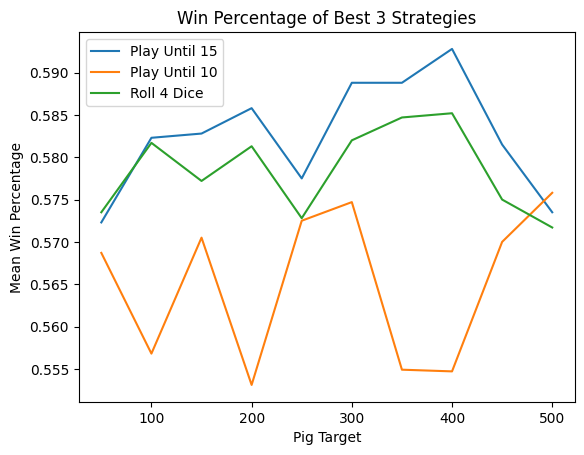

In [4]:
To_Plot = Pig.Sim_to_Plot(Named_Strategies,Sim_Res)

import matplotlib.pyplot as plt

win_15 = To_Plot["Until_15"]
win_10 = To_Plot["Until_10"]
win_roll_4 = To_Plot["Roll_4"]

xpoints = list(Target_Values)

labels = ["Play Until 15", "Play Until 10", "Roll 4 Dice"]

plt.plot(xpoints, win_15, label=labels[0])
plt.plot(xpoints, win_10, label=labels[1])
plt.plot(xpoints, win_roll_4, label=labels[2])

plt.title("Win Percentage of Best 3 Strategies")
plt.xlabel("Pig Target")
plt.ylabel("Mean Win Percentage")

plt.legend()
plt.show()

This graph illustrates that none of the three best strategies follow a consistent pattern as the target increases. This likely illustrates that we have not used enough macroreplications in our simulation, however, we aimed to keep the simulation time relatively low. 

This does seem to suggest that rolling dice until 15 is generally the best strategy, however we also note that the win rate remains below 65%. This is likely due to the huge advantage gained from going first. We posit that in the case where both players are allowed to win if they reach the target in the same number of turns, more consistent results would be likely to appear with greater win percentages.

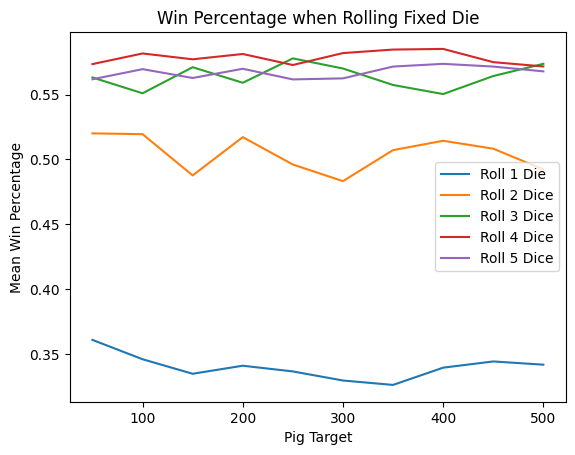

In [5]:
win_roll_1 = To_Plot["Roll_1"]
win_roll_2 = To_Plot["Roll_2"]
win_roll_3 = To_Plot["Roll_3"]
win_roll_4 = To_Plot["Roll_4"]
win_roll_5 = To_Plot["Roll_5"]

xpoints = list(Target_Values)

labels = ["Roll 1 Die", "Roll 2 Dice", "Roll 3 Dice", "Roll 4 Dice", "Roll 5 Dice"]

plt.plot(xpoints, win_roll_1, label=labels[0])
plt.plot(xpoints, win_roll_2, label=labels[1])
plt.plot(xpoints, win_roll_3, label=labels[2])
plt.plot(xpoints, win_roll_4, label = labels[3])
plt.plot(xpoints, win_roll_5, label = labels[4])

plt.title("Win Percentage when Rolling Fixed Die")
plt.xlabel("Pig Target")
plt.ylabel("Mean Win Percentage")

plt.legend()
plt.show()

Looking at the strategies that involve rolling a fixed number of dice, we see that rolling only once or twice is markedly worse than the other three options. Further, when we roll more than four dice, the win percentage begins to decrease again. It may be interesting to assess if this behaviour continues as we continue beyond 5 dice.

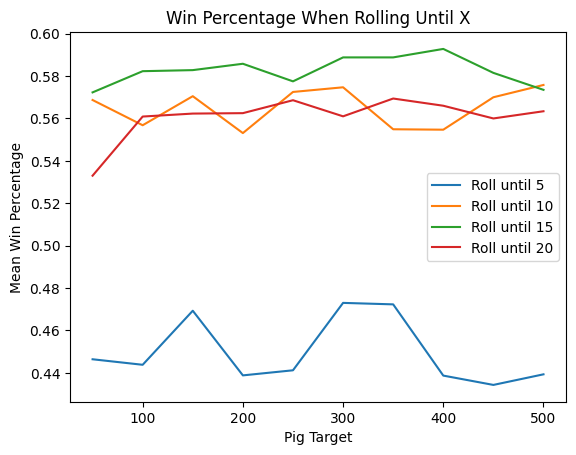

In [6]:
win_until_5 = To_Plot["Until_5"]
win_until_10 = To_Plot["Until_10"]
win_until_15 = To_Plot["Until_15"]
win_until_20 = To_Plot["Until_20"]

xpoints = list(Target_Values)

labels = ["Roll until 5", "Roll until 10", "Roll until 15", "Roll until 20"]

plt.plot(xpoints, win_until_5, label=labels[0])
plt.plot(xpoints, win_until_10, label=labels[1])
plt.plot(xpoints, win_until_15, label=labels[2])
plt.plot(xpoints, win_until_20, label = labels[3])

plt.title("Win Percentage When Rolling Until X")
plt.xlabel("Pig Target")
plt.ylabel("Mean Win Percentage")

plt.legend()
plt.show()

This graph also suggests that rolling until 5, which is most comparable to rolling 1 or 2 dice is unfavourable. We see that rolling until 15 is greater than both values either side of it for all targets, though rolling until 10 and 20 appear to be equally preferable at various times.

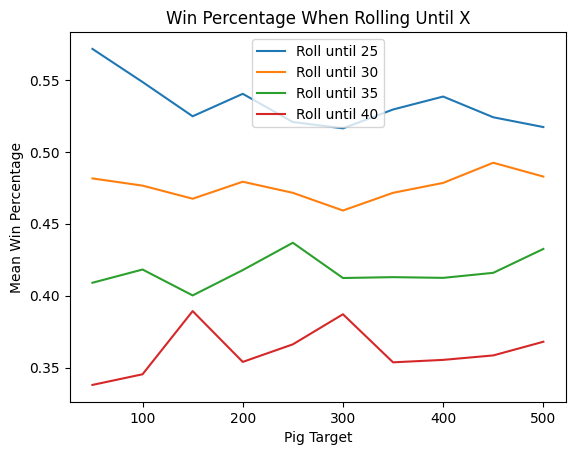

In [7]:
win_until_25 = To_Plot["Until_25"]
win_until_30 = To_Plot["Until_30"]
win_until_35 = To_Plot["Until_35"]
win_until_40 = To_Plot["Until_40"]

xpoints = list(Target_Values)

labels = ["Roll until 25", "Roll until 30", "Roll until 35", "Roll until 40"]

plt.plot(xpoints, win_until_25, label=labels[0])
plt.plot(xpoints, win_until_30, label=labels[1])
plt.plot(xpoints, win_until_35, label=labels[2])
plt.plot(xpoints, win_until_40, label = labels[3])

plt.title("Win Percentage When Rolling Until X")
plt.xlabel("Pig Target")
plt.ylabel("Mean Win Percentage")

plt.legend() 
plt.show()

Lastly we see that as the holdout value continues to increase, the win percentage of these strategies continues to drop. This is to be expected as we become far more likely to roll a 1 on each turn.

# Simulation 2 - Draws Allowed.

In [8]:
Named_Strategies = {Pig.Roll_n_times(x) :  f"Roll_{x}" for x in range(1,6)}

Named_Strategies.update({Pig.Roll_until_n(n) : f"Until_{n}" for n in range(5,45,5)})

import random
random.seed(369)

Draw_Res = Pig.Simulation(Strategies = Named_Strategies, n_plays = 1000, Draw = True, Target_vals = Target_Values, DiceRange = (1,6), n_dice= 1)

In [9]:
Best_Draw_Strategies = Pig.Max_Strats(Named_Strategies,Sim_Res)
print(Best_Draw_Strategies)

['Roll_4', 'Until_15', 'Until_15', 'Until_15', 'Roll_3', 'Until_15', 'Until_15', 'Until_15', 'Until_15', 'Until_10']


The same strategies appear when we allow both players to win as in the case where draws are not allowed as we might expect. 

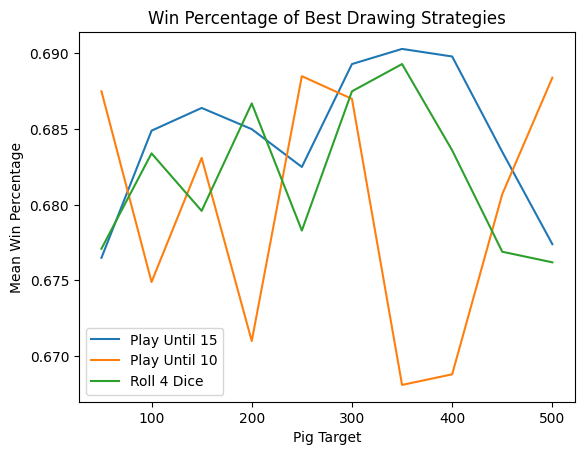

In [10]:
Draw_To_Plot = Pig.Sim_to_Plot(Named_Strategies,Draw_Res)

Draw_15 = Draw_To_Plot["Until_15"]
Draw_10 = Draw_To_Plot["Until_10"]
Draw_roll_4 = Draw_To_Plot["Roll_4"]

xpoints = list(Target_Values)

labels = ["Play Until 15", "Play Until 10", "Roll 4 Dice"]

plt.plot(xpoints, Draw_15, label=labels[0])
plt.plot(xpoints, Draw_10, label=labels[1])
plt.plot(xpoints, Draw_roll_4, label=labels[2])

plt.title("Win Percentage of Best Drawing Strategies")
plt.xlabel("Pig Target")
plt.ylabel("Mean Win Percentage")

plt.legend()
plt.show()

As expected, when player two may also win, the win percentage is much greater. Still, no clear patter emerges even with effectively twice the number of macroreplications as the game is now symmetric in regards to player position. Still, this adds to our belief that these are the three best strategies. It may be of further interest to the keen Pig player to explore a finer parameter range around these optimal values, or investigate various other more complex strategies.